# RQ2 Vulnerability Detection Analysis

**Purpose**: Analyze vulnerability detection results from RQ2 experiments comparing Dual-Agent vs Multi-Agent approaches.

**Datasets**: 16 vulnerability detection experiments (8 pods × 2 experiments per pod)
- **Dual-Agent (DA)**: 2-agent approach (Security Researcher + Moderator)
- **Multi-Agent (MA)**: 4-agent approach (Security Researcher + Code Author + Moderator + Review Board)

**Research Questions**:
- **RQ2.1**: How do dual-agent and multi-agent approaches compare in vulnerability detection accuracy?
- **RQ2.2**: What is the impact of prompting strategy (zero-shot vs few-shot)?
- **RQ2.3**: How do model size (4B vs 30B) and reasoning capabilities (Instruct vs Thinking) affect performance?
- **RQ2.4**: What are the energy efficiency tradeoffs between different configurations?

**Date**: November 17, 2025

## 1. Setup & Data Loading

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Paths
PROJECT_ROOT = Path.cwd().parent
RESULTS_DIR = PROJECT_ROOT / 'results'
OUTPUT_DIR = PROJECT_ROOT / 'results' / 'analysis' / 'rq2'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"📂 Project Root: {PROJECT_ROOT}")
print(f"📊 Results Directory: {RESULTS_DIR}")
print(f"💾 Output Directory: {OUTPUT_DIR}")

📂 Project Root: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green
📊 Results Directory: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results
💾 Output Directory: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis/rq2


## 2. Load RQ2 Results from All Pods

Pod configuration:
- **Pod 1**: 4B-Instruct, Zero-Shot
- **Pod 2**: 4B-Thinking, Zero-Shot  
- **Pod 3**: 4B-Instruct, Few-Shot
- **Pod 4**: 4B-Thinking, Few-Shot
- **Pod 5**: 30B-Instruct, Zero-Shot
- **Pod 6**: 30B-Thinking, Zero-Shot
- **Pod 7**: 30B-Instruct, Few-Shot
- **Pod 8**: 30B-Thinking, Few-Shot

In [49]:
# Define pod configurations
pod_configs = {
    'pod1': {'model_size': '4B', 'model_type': 'Instruct', 'prompting': 'Zero-shot'},
    'pod2': {'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Zero-shot'},
    'pod3': {'model_size': '4B', 'model_type': 'Instruct', 'prompting': 'Few-shot'},
    'pod4': {'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
    'pod5': {'model_size': '30B', 'model_type': 'Instruct', 'prompting': 'Zero-shot'},
    'pod6': {'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Zero-shot'},
    'pod7': {'model_size': '30B', 'model_type': 'Instruct', 'prompting': 'Few-shot'},
    'pod8': {'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
}

# Load all vulnerability detection results
all_results = []

for pod_name, config in pod_configs.items():
    pod_dir = RESULTS_DIR / f'runpod_rq2_{pod_name}'
    
    # Handle nested results directories for some pods
    if (pod_dir / 'results').exists():
        pod_dir = pod_dir / 'results'
    
    # Find DA and MA vulnerability detection files
    da_files = list(pod_dir.glob('DA-vuln-*_classification_report.csv'))
    ma_files = list(pod_dir.glob('MA-vuln-*_classification_report.csv'))
    
    for file in da_files + ma_files:
        agent_type = 'Dual-Agent' if 'DA-' in file.name else 'Multi-Agent'
        
        # Load classification report
        df = pd.read_csv(file)
        
        # Extract metrics (assuming weighted avg row)
        weighted_avg = df[df.iloc[:, 0].str.contains('weighted avg', case=False, na=False)]
        
        if not weighted_avg.empty:
            result = {
                'pod': pod_name,
                'agent_type': agent_type,
                'model_size': config['model_size'],
                'model_type': config['model_type'],
                'prompting': config['prompting'],
                'precision': weighted_avg['precision'].values[0],
                'recall': weighted_avg['recall'].values[0],
                'f1_score': weighted_avg['f1-score'].values[0],
                'support': weighted_avg['support'].values[0],
                'file': file.name
            }
            all_results.append(result)

# Create DataFrame
df_vuln = pd.DataFrame(all_results)

print(f"\n📊 Loaded {len(df_vuln)} vulnerability detection experiments")
print(f"\nColumns: {list(df_vuln.columns)}")
df_vuln.head(10)


📊 Loaded 17 vulnerability detection experiments

Columns: ['pod', 'agent_type', 'model_size', 'model_type', 'prompting', 'precision', 'recall', 'f1_score', 'support', 'file']


,pod,agent_type,model_size,model_type,prompting,precision,recall,f1_score,support,file
0,pod1,Dual-Agent,4B,Instruct,Zero-shot,0.494059,0.494819,0.478143,386.0,DA-vuln-two-zero_shot_Qwen-Qwen3-4B-Instruct-2...
1,pod1,Multi-Agent,4B,Instruct,Zero-shot,0.247403,0.497396,0.330444,384.0,MA-vuln-four-zero_shot_Qwen-Qwen3-4B-Instruct-...
2,pod2,Dual-Agent,4B,Thinking,Zero-shot,0.250000,0.500000,0.333333,386.0,DA-vuln-two-zero_shot_Qwen-Qwen3-4B-Instruct-2...
3,pod2,Dual-Agent,4B,Thinking,Zero-shot,0.480372,0.492228,0.401910,386.0,DA-vuln-two-zero_shot_Qwen-Qwen3-4B-Thinking-2...
4,pod2,Multi-Agent,4B,Thinking,Zero-shot,0.245434,0.489583,0.326959,384.0,MA-vuln-four-zero_shot_Qwen-Qwen3-4B-Thinking-...
5,pod3,Dual-Agent,4B,Instruct,Few-shot,0.494663,0.494819,0.491099,386.0,DA-vuln-two-few_shot_Qwen-Qwen3-4B-Instruct-25...
6,pod3,Multi-Agent,4B,Instruct,Few-shot,0.500000,0.500000,0.412453,386.0,MA-vuln-four-few_shot_Qwen-Qwen3-4B-Instruct-2...
7,pod4,Dual-Agent,4B,Thinking,Few-shot,0.528452,0.523316,0.500787,386.0,DA-vuln-two-few_shot_Qwen-Qwen3-4B-Thinking-25...
8,pod4,Multi-Agent,4B,Thinking,Few-shot,0.499349,0.498701,0.336453,385.0,MA-vuln-four-few_shot_Qwen-Qwen3-4B-Thinking-2...
9,pod5,Dual-Agent,30B,Instruct,Zero-shot,0.476348,0.484456,0.436132,386.0,DA-vuln-two-zero_shot_Qwen-Qwen3-30B-A3B-Instr...


## 3. Data Preprocessing

In [50]:
# Convert to percentages for better readability
for col in ['precision', 'recall', 'f1_score']:
    df_vuln[f'{col}_pct'] = df_vuln[col] * 100

# Load energy data from emissions.csv files
# IMPORTANT: Aggregate by experiment type, not by entire pod!
energy_data = []

def extract_experiment_type(project_name):
    """Extract experiment type from project_name in emissions.csv"""
    if 'DA-vuln' in project_name:
        return 'DA-vuln'
    elif 'DA-code' in project_name:
        return 'DA-code'
    elif 'MA-vuln' in project_name:
        return 'MA-vuln'
    elif 'MA-code' in project_name:
        return 'MA-code'
    else:
        return 'Unknown'

for pod_name, config in pod_configs.items():
    pod_dir = RESULTS_DIR / f'runpod_rq2_{pod_name}'
    
    # Handle nested results directories
    emissions_file = pod_dir / 'emissions.csv'
    if not emissions_file.exists():
        emissions_file = pod_dir / 'results' / 'emissions.csv'
    
    if emissions_file.exists():
        df_emissions = pd.read_csv(emissions_file)
        
        # Extract experiment type from project_name
        df_emissions['experiment_type'] = df_emissions['project_name'].apply(extract_experiment_type)
        
        # Group by experiment type and sum energy/emissions
        energy_by_exp = df_emissions.groupby('experiment_type').agg({
            'energy_consumed': 'sum',
            'emissions': 'sum'
        }).reset_index()
        
        # Add pod info and append
        for _, row in energy_by_exp.iterrows():
            energy_data.append({
                'pod': pod_name,
                'experiment_type': row['experiment_type'],
                'energy_kwh': row['energy_consumed'],
                'emissions_kg': row['emissions']
            })

df_energy = pd.DataFrame(energy_data)

# Filter for vulnerability detection experiments only (DA-vuln and MA-vuln)
df_energy_vuln = df_energy[df_energy['experiment_type'].isin(['DA-vuln', 'MA-vuln'])].copy()

# Map experiment_type to agent_type for merging
df_energy_vuln['agent_type'] = df_energy_vuln['experiment_type'].map({
    'DA-vuln': 'Dual-Agent',
    'MA-vuln': 'Multi-Agent'
})

# Merge energy data with vulnerability results
df_vuln = df_vuln.merge(
    df_energy_vuln[['pod', 'agent_type', 'energy_kwh', 'emissions_kg']], 
    on=['pod', 'agent_type'], 
    how='left'
)

print("\n✅ Data preprocessing complete!")
print(f"\nDataset shape: {df_vuln.shape}")
print(f"\nEnergy data breakdown:")
print(df_energy_vuln.groupby(['pod', 'experiment_type']).agg({'energy_kwh': 'sum'}).head(10))
df_vuln.head()


✅ Data preprocessing complete!

Dataset shape: (17, 15)

Energy data breakdown:
                      energy_kwh
pod  experiment_type            
pod1 DA-vuln            0.276571
     MA-vuln            1.066736
pod2 DA-vuln            2.149720
     MA-vuln            3.521474
pod3 DA-vuln            0.226524
     MA-vuln            0.352151
pod4 DA-vuln            1.727872
     MA-vuln            3.052418
pod5 DA-vuln            0.317048
     MA-vuln            0.664664


,pod,agent_type,model_size,model_type,prompting,precision,recall,f1_score,support,file,precision_pct,recall_pct,f1_score_pct,energy_kwh,emissions_kg
0,pod1,Dual-Agent,4B,Instruct,Zero-shot,0.494059,0.494819,0.478143,386.0,DA-vuln-two-zero_shot_Qwen-Qwen3-4B-Instruct-2...,49.405934,49.481865,47.814331,0.276571,0.047029
1,pod1,Multi-Agent,4B,Instruct,Zero-shot,0.247403,0.497396,0.330444,384.0,MA-vuln-four-zero_shot_Qwen-Qwen3-4B-Instruct-...,24.740262,49.739583,33.044384,1.066736,0.181391
2,pod2,Dual-Agent,4B,Thinking,Zero-shot,0.250000,0.500000,0.333333,386.0,DA-vuln-two-zero_shot_Qwen-Qwen3-4B-Instruct-2...,25.000000,50.000000,33.333333,2.149720,0.365545
3,pod2,Dual-Agent,4B,Thinking,Zero-shot,0.480372,0.492228,0.401910,386.0,DA-vuln-two-zero_shot_Qwen-Qwen3-4B-Thinking-2...,48.037155,49.222798,40.190994,2.149720,0.365545
4,pod2,Multi-Agent,4B,Thinking,Zero-shot,0.245434,0.489583,0.326959,384.0,MA-vuln-four-zero_shot_Qwen-Qwen3-4B-Thinking-...,24.543416,48.958333,32.695950,3.521474,0.598802


## 4. RQ2.1: Dual-Agent vs Multi-Agent Comparison

📊 Dual-Agent vs Multi-Agent Performance:

             precision_pct  recall_pct  f1_score_pct
agent_type                                          
Dual-Agent           47.31       50.23         45.88
Multi-Agent          44.12       50.16         36.37


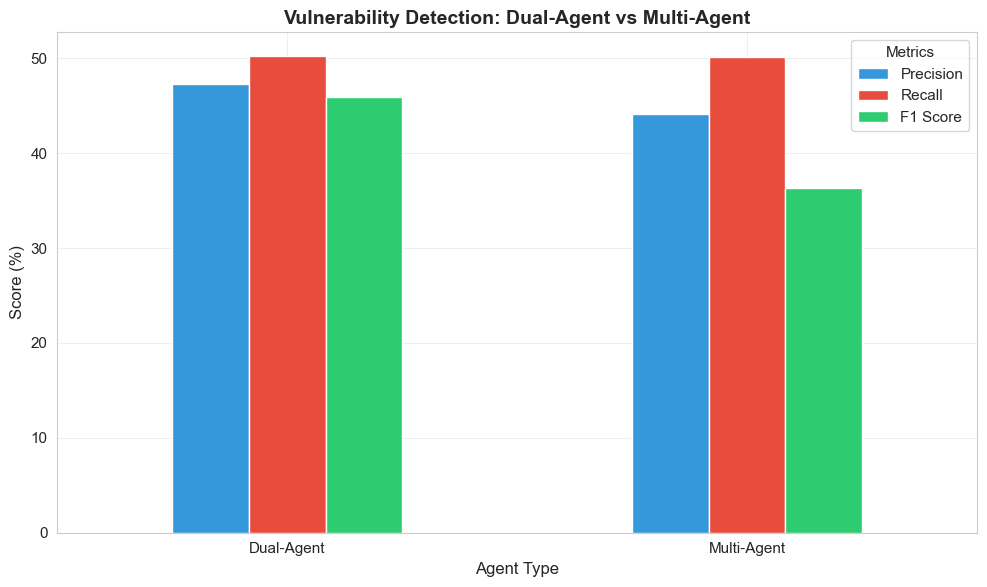


📊 T-test (DA vs MA F1 Score): t=3.220, p=0.006
   ✅ Statistically significant difference!


In [51]:
# Compare DA vs MA performance
agent_comparison = df_vuln.groupby('agent_type')[['precision_pct', 'recall_pct', 'f1_score_pct']].mean()

print("📊 Dual-Agent vs Multi-Agent Performance:\n")
print(agent_comparison.round(2))

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
agent_comparison.plot(kind='bar', ax=ax, rot=0, color=['#3498DB', '#E74C3C', '#2ECC71'])
ax.set_title('Vulnerability Detection: Dual-Agent vs Multi-Agent', fontsize=14, fontweight='bold')
ax.set_xlabel('Agent Type', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.legend(title='Metrics', labels=['Precision', 'Recall', 'F1 Score'])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_da_vs_ma_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistical test
from scipy import stats
da_f1 = df_vuln[df_vuln['agent_type'] == 'Dual-Agent']['f1_score_pct']
ma_f1 = df_vuln[df_vuln['agent_type'] == 'Multi-Agent']['f1_score_pct']
t_stat, p_value = stats.ttest_ind(da_f1, ma_f1)
print(f"\n📊 T-test (DA vs MA F1 Score): t={t_stat:.3f}, p={p_value:.3f}")
if p_value < 0.05:
    print("   ✅ Statistically significant difference!")
else:
    print("   ⚠️  No statistically significant difference")

## 5. RQ2.2: Prompting Strategy Analysis

📊 Zero-shot vs Few-shot Performance:

           precision_pct  recall_pct  f1_score_pct
prompting                                         
Few-shot           50.72       50.53         44.30
Zero-shot          41.44       49.90         38.83


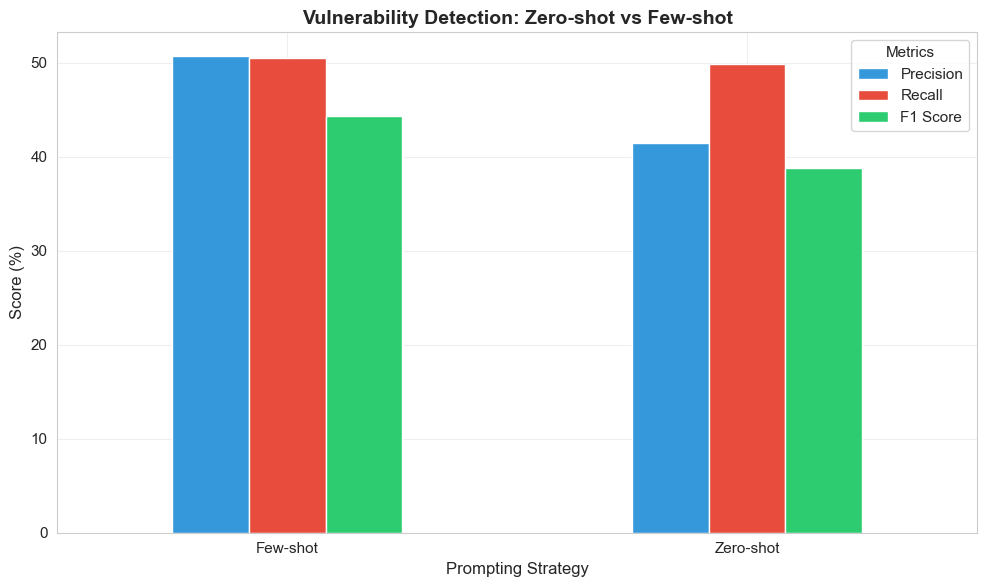

In [52]:
# Compare Zero-shot vs Few-shot
prompting_comparison = df_vuln.groupby('prompting')[['precision_pct', 'recall_pct', 'f1_score_pct']].mean()

print("📊 Zero-shot vs Few-shot Performance:\n")
print(prompting_comparison.round(2))

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
prompting_comparison.plot(kind='bar', ax=ax, rot=0, color=['#3498DB', '#E74C3C', '#2ECC71'])
ax.set_title('Vulnerability Detection: Zero-shot vs Few-shot', fontsize=14, fontweight='bold')
ax.set_xlabel('Prompting Strategy', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.legend(title='Metrics', labels=['Precision', 'Recall', 'F1 Score'])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_prompting_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. RQ2.3: Model Configuration Analysis

📊 4B vs 30B Model Performance:

            precision_pct  recall_pct  f1_score_pct
model_size                                         
30B                 50.59       50.53         42.84
4B                  41.55       49.90         40.13

📊 Instruct vs Thinking Performance:

            precision_pct  recall_pct  f1_score_pct
model_type                                         
Instruct            44.15       50.36         43.71
Thinking            47.28       50.06         39.36


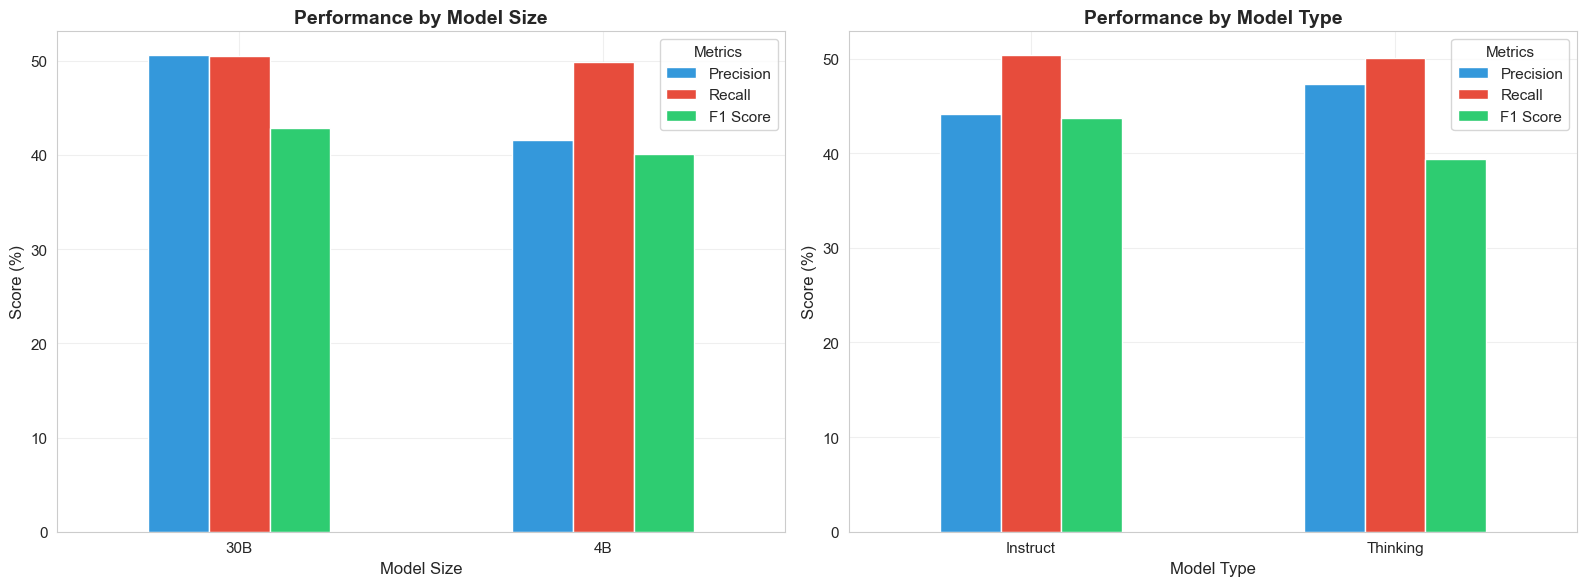

In [53]:
# Model size comparison
size_comparison = df_vuln.groupby('model_size')[['precision_pct', 'recall_pct', 'f1_score_pct']].mean()

print("📊 4B vs 30B Model Performance:\n")
print(size_comparison.round(2))

# Model type comparison
type_comparison = df_vuln.groupby('model_type')[['precision_pct', 'recall_pct', 'f1_score_pct']].mean()

print("\n📊 Instruct vs Thinking Performance:\n")
print(type_comparison.round(2))

# Combined visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

size_comparison.plot(kind='bar', ax=axes[0], rot=0, color=['#3498DB', '#E74C3C', '#2ECC71'])
axes[0].set_title('Performance by Model Size', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Model Size', fontsize=12)
axes[0].set_ylabel('Score (%)', fontsize=12)
axes[0].legend(title='Metrics', labels=['Precision', 'Recall', 'F1 Score'])
axes[0].grid(True, alpha=0.3)

type_comparison.plot(kind='bar', ax=axes[1], rot=0, color=['#3498DB', '#E74C3C', '#2ECC71'])
axes[1].set_title('Performance by Model Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Model Type', fontsize=12)
axes[1].set_ylabel('Score (%)', fontsize=12)
axes[1].legend(title='Metrics', labels=['Precision', 'Recall', 'F1 Score'])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_model_configuration_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. RQ2.4: Energy Efficiency Analysis

📊 Energy Consumption by Agent Type:

             energy_kwh  emissions_kg
agent_type                           
Dual-Agent        1.203         0.205
Multi-Agent       1.811         0.308


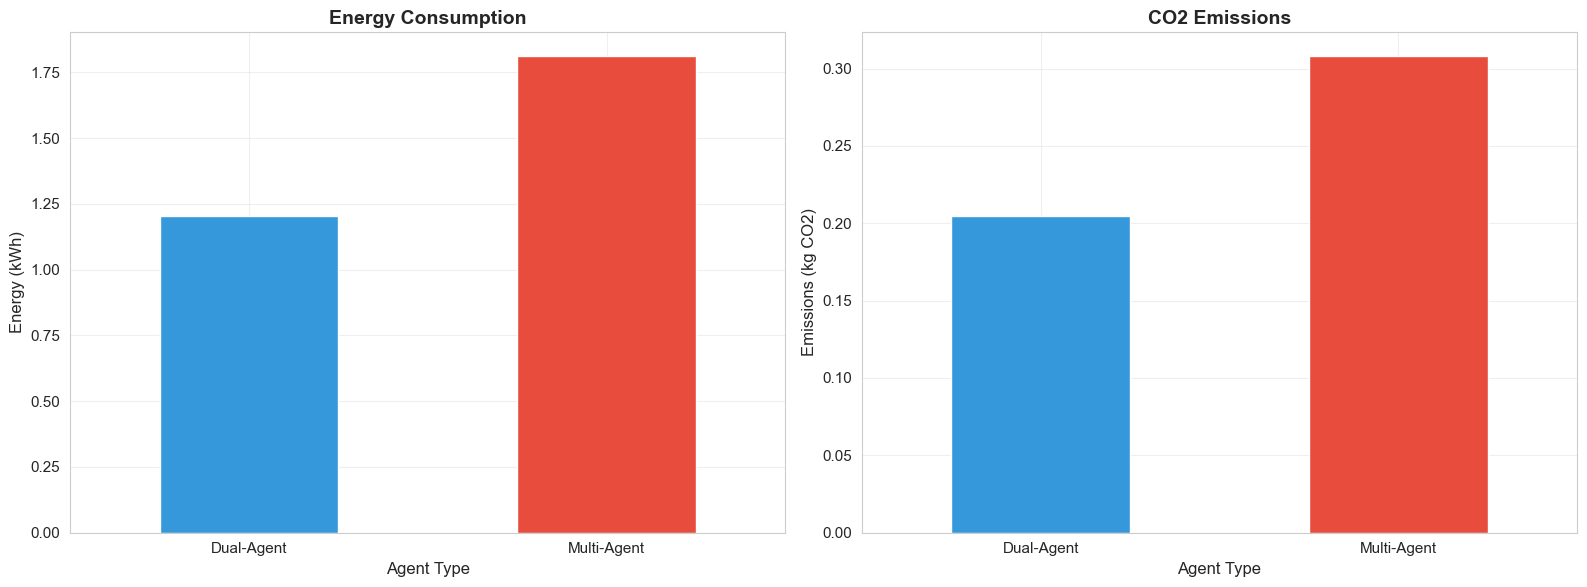

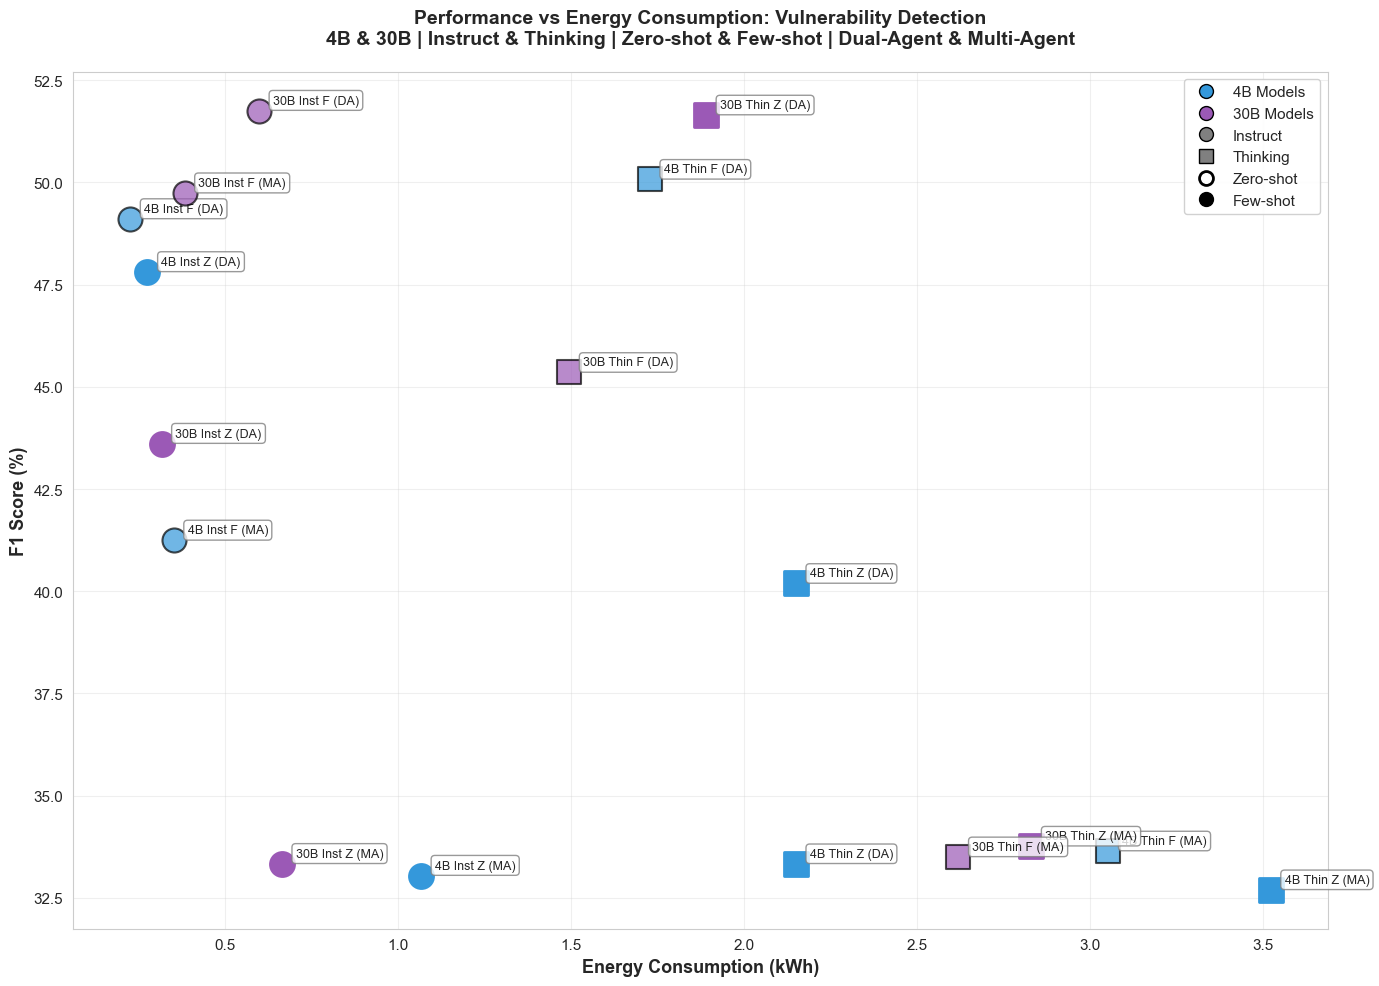


📊 Top 5 Most Energy-Efficient Configurations (F1 per kWh):
 pod  agent_type model_size model_type prompting  f1_score_pct  energy_kwh  efficiency_f1_per_kwh
pod3  Dual-Agent         4B   Instruct  Few-shot     49.109914    0.226524             216.798220
pod1  Dual-Agent         4B   Instruct Zero-shot     47.814331    0.276571             172.882399
pod5  Dual-Agent        30B   Instruct Zero-shot     43.613234    0.317048             137.560355
pod7 Multi-Agent        30B   Instruct  Few-shot     49.741022    0.383636             129.656865
pod3 Multi-Agent         4B   Instruct  Few-shot     41.245317    0.352151             117.124116


In [54]:
# Energy by agent type
energy_by_agent = df_vuln.groupby('agent_type')[['energy_kwh', 'emissions_kg']].mean()

print("📊 Energy Consumption by Agent Type:\n")
print(energy_by_agent.round(3))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

energy_by_agent['energy_kwh'].plot(kind='bar', ax=axes[0], rot=0, color=['#3498DB', '#E74C3C'])
axes[0].set_title('Energy Consumption', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Agent Type', fontsize=12)
axes[0].set_ylabel('Energy (kWh)', fontsize=12)
axes[0].grid(True, alpha=0.3)

energy_by_agent['emissions_kg'].plot(kind='bar', ax=axes[1], rot=0, color=['#3498DB', '#E74C3C'])
axes[1].set_title('CO2 Emissions', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Agent Type', fontsize=12)
axes[1].set_ylabel('Emissions (kg CO2)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_energy_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Performance vs Energy Tradeoff Scatter Plot
fig, ax = plt.subplots(figsize=(14, 10))

# Define colors and markers
colors_map = {'4B': '#3498DB', '30B': '#9B59B6'}
base_markers_map = {'Instruct': 'o', 'Thinking': 's'}

# Remove rows with missing energy data
df_plot_energy = df_vuln.dropna(subset=['energy_kwh', 'f1_score_pct']).copy()

# Plot each configuration
for _, row in df_plot_energy.iterrows():
    color = colors_map[row['model_size']]
    base_marker = base_markers_map[row['model_type']]
    
    # Use hollow markers for Zero-shot, filled for Few-shot
    if row['prompting'] == 'Zero-shot':
        facecolor = 'none'
        edgecolor = color
        linewidth = 2
    else:  # Few-shot
        facecolor = color
        edgecolor = 'black'
        linewidth = 1.5
    
    # Create label with agent type
    prompting_abbr = 'Z' if row['prompting'] == 'Zero-shot' else 'F'
    size_abbr = row['model_size']
    type_abbr = row['model_type'][:4]
    agent_abbr = 'DA' if row['agent_type'] == 'Dual-Agent' else 'MA'
    
    label = f"{size_abbr} {type_abbr} {prompting_abbr} ({agent_abbr})"
    
    # Plot point
    ax.scatter(
        row['energy_kwh'],
        row['f1_score_pct'],
        s=300,
        c=facecolor if facecolor != 'none' else edgecolor,
        marker=base_marker,
        edgecolors=edgecolor,
        linewidths=linewidth,
        alpha=0.7 if facecolor != 'none' else 1.0,
        facecolors=facecolor,
        zorder=3
    )
    
    # Add label
    ax.annotate(
        label,
        (row['energy_kwh'], row['f1_score_pct']),
        xytext=(10, 5),
        textcoords='offset points',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8)
    )

# Customize plot
ax.set_xlabel('Energy Consumption (kWh)', fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score (%)', fontsize=13, fontweight='bold')
ax.set_title('Performance vs Energy Consumption: Vulnerability Detection\n4B & 30B | Instruct & Thinking | Zero-shot & Few-shot | Dual-Agent & Multi-Agent',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, zorder=0)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498DB', markersize=10, 
           markeredgecolor='black', label='4B Models', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#9B59B6', markersize=10, 
           markeredgecolor='black', label='30B Models', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, 
           markeredgecolor='black', label='Instruct', linewidth=0),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, 
           markeredgecolor='black', label='Thinking', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markersize=10, 
           markeredgecolor='black', markeredgewidth=2, label='Zero-shot', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, 
           markeredgecolor='black', label='Few-shot', linewidth=0)
]
ax.legend(handles=legend_elements, loc='best', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_vuln_performance_vs_energy.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate and display efficiency metrics
df_vuln['efficiency_f1_per_kwh'] = df_vuln['f1_score_pct'] / df_vuln['energy_kwh']
print("\n📊 Top 5 Most Energy-Efficient Configurations (F1 per kWh):")
efficiency_cols = ['pod', 'agent_type', 'model_size', 'model_type', 'prompting', 'f1_score_pct', 'energy_kwh', 'efficiency_f1_per_kwh']
print(df_vuln.nlargest(5, 'efficiency_f1_per_kwh')[efficiency_cols].to_string(index=False))

## 7.5. Token Length vs Performance Analysis

In [55]:
# Load output token data from detailed_results.jsonl files
import tiktoken

# Initialize tokenizer (using cl100k_base which is close to Qwen tokenization)
try:
    encoding = tiktoken.get_encoding("cl100k_base")
except:
    print("Installing tiktoken...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'tiktoken', '-q'])
    import tiktoken
    encoding = tiktoken.get_encoding("cl100k_base")

token_data = []

for pod_name, config in pod_configs.items():
    pod_dir = RESULTS_DIR / f'runpod_rq2_{pod_name}'
    
    # Handle nested results directories
    if (pod_dir / 'results').exists():
        pod_dir = pod_dir / 'results'
    
    # Find DA and MA vulnerability JSONL files
    da_files = list(pod_dir.glob('DA-vuln-*_detailed_results.jsonl'))
    ma_files = list(pod_dir.glob('MA-vuln-*_detailed_results.jsonl'))
    
    for file in da_files + ma_files:
        agent_type = 'Dual-Agent' if 'DA-' in file.name else 'Multi-Agent'
        
        # Load JSONL and calculate average output tokens
        total_tokens = 0
        sample_count = 0
        
        with open(file, 'r') as f:
            for line in f:
                try:
                    data = json.loads(line)
                    
                    # Extract output text based on agent type
                    if agent_type == 'Dual-Agent':
                        output_text = data.get('reasoning', '')
                    else:
                        output_text = data.get('full_discussion', data.get('reasoning', ''))
                    
                    # Count tokens
                    if output_text:
                        tokens = encoding.encode(str(output_text))
                        total_tokens += len(tokens)
                        sample_count += 1
                except:
                    continue
        
        if sample_count > 0:
            avg_tokens = total_tokens / sample_count
            token_data.append({
                'pod': pod_name,
                'agent_type': agent_type,
                'avg_output_tokens': avg_tokens,
                'total_samples': sample_count
            })

df_tokens = pd.DataFrame(token_data)

# Merge with main dataframe
df_vuln = df_vuln.merge(
    df_tokens[['pod', 'agent_type', 'avg_output_tokens']], 
    on=['pod', 'agent_type'], 
    how='left'
)

print(f"\n✅ Token analysis complete!")
print(f"\nAverage output tokens by configuration:")
print(df_vuln.groupby(['model_size', 'model_type', 'agent_type'])['avg_output_tokens'].mean().round(0))
df_vuln[['pod', 'agent_type', 'model_size', 'model_type', 'prompting', 'f1_score_pct', 'avg_output_tokens']].head(10)


✅ Token analysis complete!

Average output tokens by configuration:
model_size  model_type  agent_type 
30B         Instruct    Dual-Agent      343.0
                        Multi-Agent    1876.0
            Thinking    Dual-Agent     1258.0
                        Multi-Agent    8959.0
4B          Instruct    Dual-Agent      298.0
                        Multi-Agent    1951.0
            Thinking    Dual-Agent      832.0
                        Multi-Agent    9972.0
Name: avg_output_tokens, dtype: float64


,pod,agent_type,model_size,model_type,prompting,f1_score_pct,avg_output_tokens
0,pod1,Dual-Agent,4B,Instruct,Zero-shot,47.814331,246.191710
1,pod1,Multi-Agent,4B,Instruct,Zero-shot,33.044384,2606.945312
2,pod2,Dual-Agent,4B,Thinking,Zero-shot,33.333333,1447.808290
3,pod2,Dual-Agent,4B,Thinking,Zero-shot,33.333333,53.000000
4,pod2,Dual-Agent,4B,Thinking,Zero-shot,40.190994,1447.808290
5,pod2,Dual-Agent,4B,Thinking,Zero-shot,40.190994,53.000000
6,pod2,Multi-Agent,4B,Thinking,Zero-shot,32.695950,10499.750000
7,pod3,Dual-Agent,4B,Instruct,Few-shot,49.109914,350.556995
8,pod3,Multi-Agent,4B,Instruct,Few-shot,41.245317,1294.292746
9,pod4,Dual-Agent,4B,Thinking,Few-shot,50.078722,1156.207254


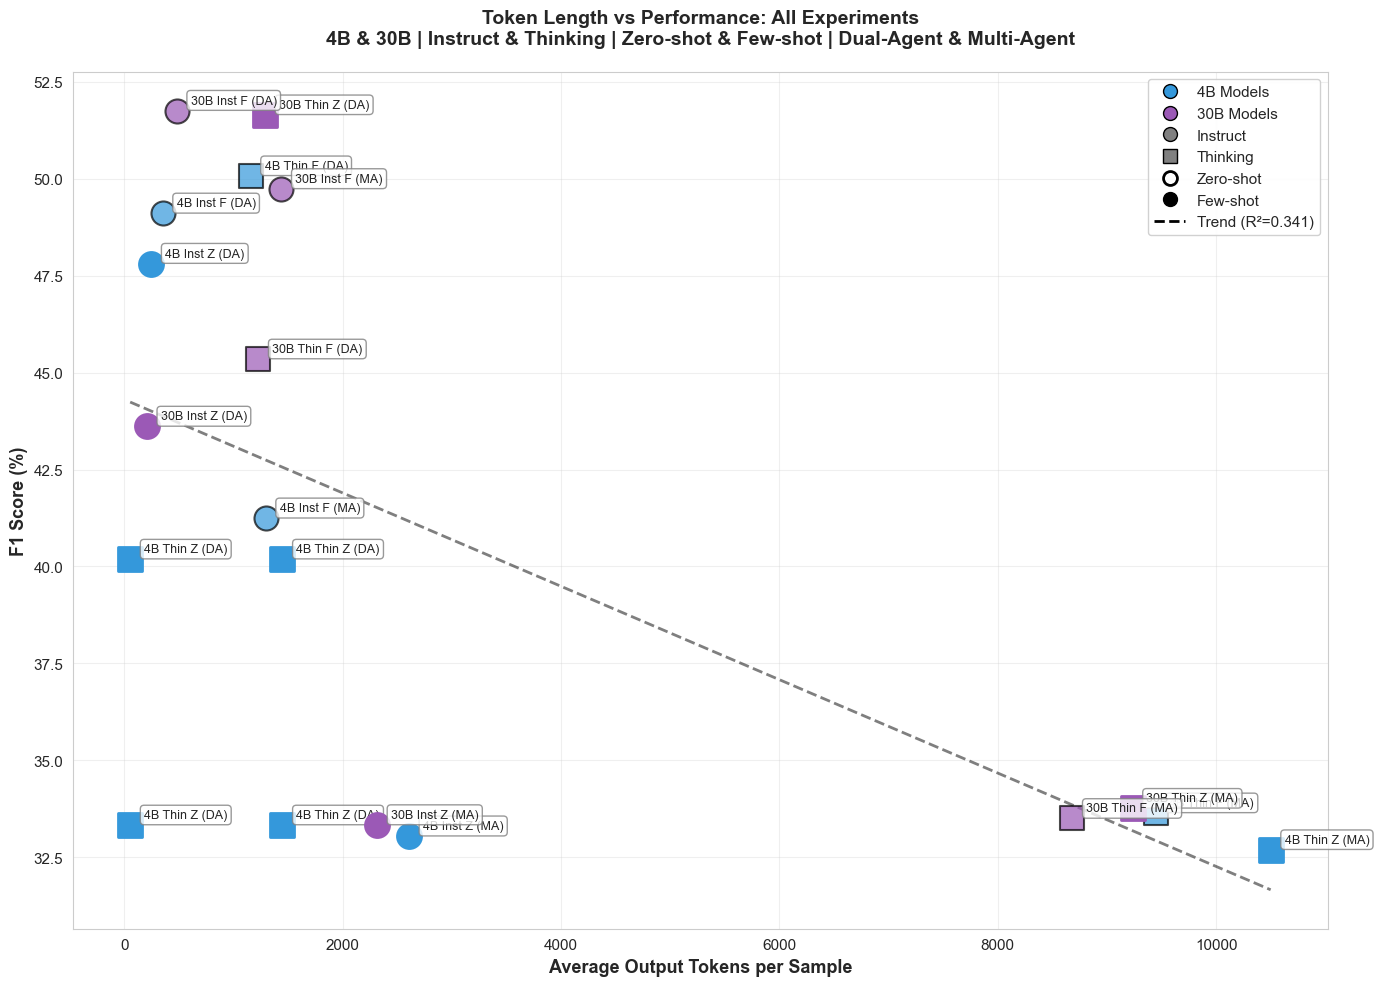


📊 Token Length vs F1 Score Analysis:
   Correlation: r = -0.584, R² = 0.341
   Slope: -0.0012 (F1% change per 1000 tokens: -1.20%)
   P-value: 0.0087 (significant)


In [56]:
# Token Length vs F1 Score Visualization (Styled like RQ1)
from scipy.stats import linregress
from matplotlib.lines import Line2D

# Remove duplicates and NaN values
df_plot = df_vuln.dropna(subset=['avg_output_tokens', 'f1_score_pct']).copy()

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Define colors and markers
colors_map = {'4B': '#3498DB', '30B': '#9B59B6'}  # Blue for 4B, Purple for 30B
base_markers_map = {'Instruct': 'o', 'Thinking': 's'}  # Circle for Instruct, Square for Thinking

# Plot each configuration
for _, row in df_plot.iterrows():
    color = colors_map[row['model_size']]
    base_marker = base_markers_map[row['model_type']]
    
    # Use hollow markers for Zero-shot, filled for Few-shot
    if row['prompting'] == 'Zero-shot':
        facecolor = 'none'
        edgecolor = color
        linewidth = 2
    else:  # Few-shot
        facecolor = color
        edgecolor = 'black'
        linewidth = 1.5
    
    # Create label with agent type
    prompting_abbr = 'Z' if row['prompting'] == 'Zero-shot' else 'F'
    size_abbr = row['model_size']
    type_abbr = row['model_type'][:4]
    agent_abbr = 'DA' if row['agent_type'] == 'Dual-Agent' else 'MA'
    
    # Format: "4B Inst Z (DA)" or "30B Thin F (MA)"
    label = f"{size_abbr} {type_abbr} {prompting_abbr} ({agent_abbr})"
    
    # Plot point
    ax.scatter(
        row['avg_output_tokens'],
        row['f1_score_pct'],
        s=300,
        c=facecolor if facecolor != 'none' else edgecolor,
        marker=base_marker,
        edgecolors=edgecolor,
        linewidths=linewidth,
        alpha=0.7 if facecolor != 'none' else 1.0,
        facecolors=facecolor,
        zorder=3
    )
    
    # Add label
    ax.annotate(
        label,
        (row['avg_output_tokens'], row['f1_score_pct']),
        xytext=(10, 5),
        textcoords='offset points',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8)
    )

# Calculate and plot trend line
slope, intercept, r_value, p_value, std_err = linregress(
    df_plot['avg_output_tokens'], 
    df_plot['f1_score_pct']
)
x_trend = np.array([df_plot['avg_output_tokens'].min(), df_plot['avg_output_tokens'].max()])
y_trend = slope * x_trend + intercept
ax.plot(x_trend, y_trend, 'k--', linewidth=2, alpha=0.5, zorder=1)

# Customize plot
ax.set_xlabel('Average Output Tokens per Sample', fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score (%)', fontsize=13, fontweight='bold')
ax.set_title('Token Length vs Performance: All Experiments\n4B & 30B | Instruct & Thinking | Zero-shot & Few-shot | Dual-Agent & Multi-Agent',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, zorder=0)

# Create custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498DB', markersize=10, 
           markeredgecolor='black', label='4B Models', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#9B59B6', markersize=10, 
           markeredgecolor='black', label='30B Models', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, 
           markeredgecolor='black', label='Instruct', linewidth=0),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, 
           markeredgecolor='black', label='Thinking', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markersize=10, 
           markeredgecolor='black', markeredgewidth=2, label='Zero-shot', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, 
           markeredgecolor='black', label='Few-shot', linewidth=0),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, 
           label=f'Trend (R²={r_value**2:.3f})')
]
ax.legend(handles=legend_elements, loc='best', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_vuln_token_length_vs_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Token Length vs F1 Score Analysis:")
print(f"   Correlation: r = {r_value:.3f}, R² = {r_value**2:.3f}")
print(f"   Slope: {slope:.4f} (F1% change per 1000 tokens: {slope*1000:.2f}%)")
print(f"   P-value: {p_value:.4f} {'(significant)' if p_value < 0.05 else '(not significant)'}")

## 8. Comprehensive Heatmap: Configuration × Performance

📊 F1 Score Heatmap (Configuration × Agent Type):

agent_type              Dual-Agent  Multi-Agent
config                                         
30B-Instruct-Few-shot        51.76        49.74
30B-Instruct-Zero-shot       43.61        33.33
30B-Thinking-Few-shot        45.35        33.50
30B-Thinking-Zero-shot       51.65        33.76
4B-Instruct-Few-shot         49.11        41.25
4B-Instruct-Zero-shot        47.81        33.04
4B-Thinking-Few-shot         50.08        33.65
4B-Thinking-Zero-shot        36.76        32.70


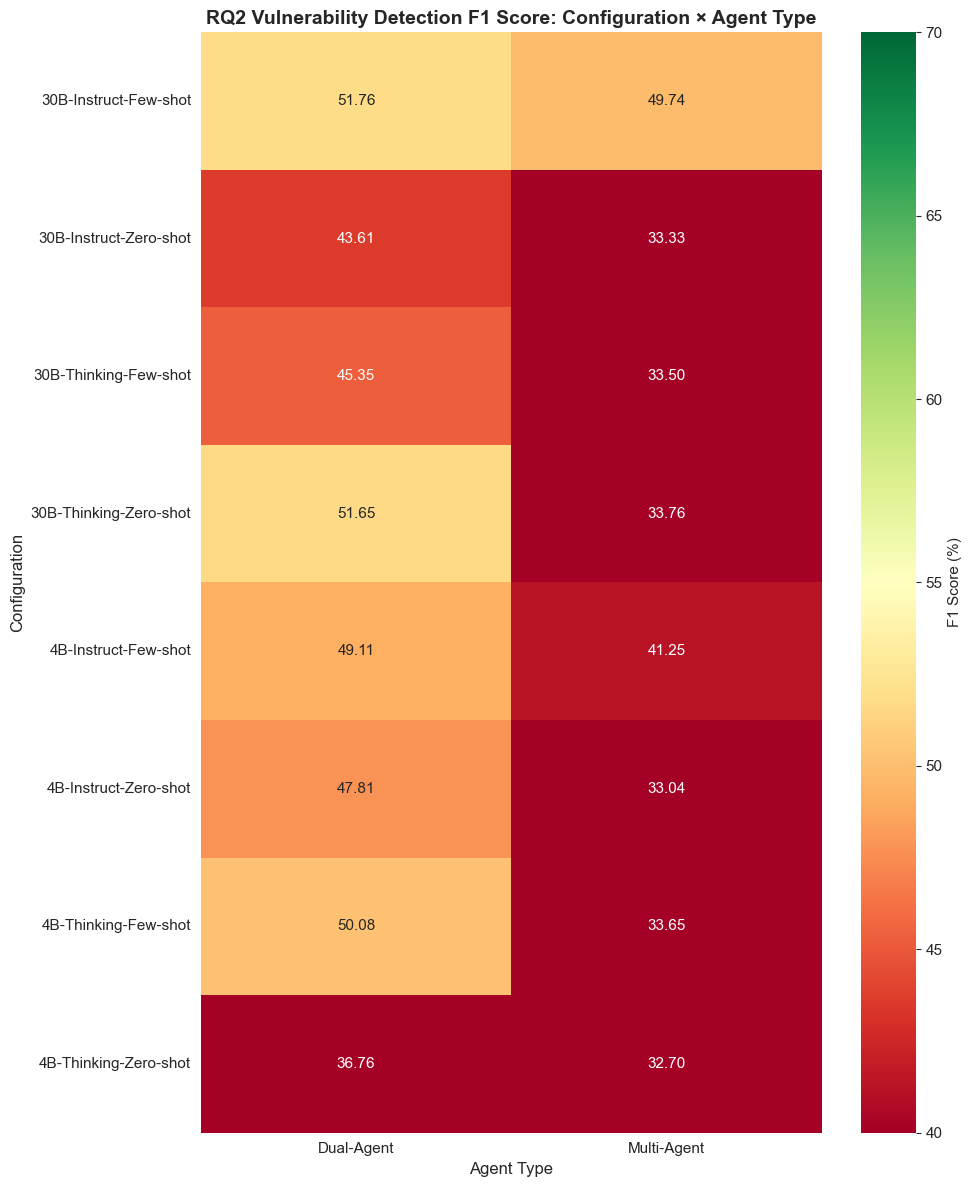

In [57]:
# Create pivot table for heatmap
# Create a combined configuration column
df_vuln['config'] = df_vuln['model_size'] + '-' + df_vuln['model_type'] + '-' + df_vuln['prompting']

heatmap_data = df_vuln.pivot_table(
    values='f1_score_pct',
    index='config',
    columns='agent_type',
    aggfunc='mean'
)

print("📊 F1 Score Heatmap (Configuration × Agent Type):\n")
print(heatmap_data.round(2))

# Visualization
plt.figure(figsize=(10, 12))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', 
            vmin=40, vmax=70, cbar_kws={'label': 'F1 Score (%)'})
plt.title('RQ2 Vulnerability Detection F1 Score: Configuration × Agent Type', 
          fontsize=14, fontweight='bold')
plt.xlabel('Agent Type', fontsize=12)
plt.ylabel('Configuration', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_configuration_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Summary & Export

In [58]:
# Export to Excel
excel_file = OUTPUT_DIR / 'rq2_vulnerability_detection_analysis.xlsx'
with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    df_vuln.to_excel(writer, sheet_name='All Results', index=False)
    agent_comparison.to_excel(writer, sheet_name='DA vs MA')
    prompting_comparison.to_excel(writer, sheet_name='Prompting Strategy')
    size_comparison.to_excel(writer, sheet_name='Model Size')
    type_comparison.to_excel(writer, sheet_name='Model Type')
    energy_by_agent.to_excel(writer, sheet_name='Energy Analysis')

print(f"\n✅ Analysis complete!")
print(f"📊 Excel file saved: {excel_file}")
print(f"🖼️  Visualizations saved to: {OUTPUT_DIR}/")

# Display final summary
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)
print(f"\nTotal Experiments Analyzed: {len(df_vuln)}")
print(f"\nBest F1 Score: {df_vuln['f1_score_pct'].max():.2f}% ({df_vuln.loc[df_vuln['f1_score_pct'].idxmax(), 'config']})")
print(f"\nAverage F1 Score by Agent Type:")
print(f"  - Dual-Agent: {df_vuln[df_vuln['agent_type'] == 'Dual-Agent']['f1_score_pct'].mean():.2f}%")
print(f"  - Multi-Agent: {df_vuln[df_vuln['agent_type'] == 'Multi-Agent']['f1_score_pct'].mean():.2f}%")
print(f"\nAverage Energy Consumption: {df_vuln['energy_kwh'].mean():.3f} kWh")
print(f"Average CO2 Emissions: {df_vuln['emissions_kg'].mean():.3f} kg")
print("\n" + "="*80)


✅ Analysis complete!
📊 Excel file saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis/rq2/rq2_vulnerability_detection_analysis.xlsx
🖼️  Visualizations saved to: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis/rq2/

FINAL SUMMARY

Total Experiments Analyzed: 19

Best F1 Score: 51.76% (30B-Instruct-Few-shot)

Average F1 Score by Agent Type:
  - Dual-Agent: 44.22%
  - Multi-Agent: 36.37%

Average Energy Consumption: 1.559 kWh
Average CO2 Emissions: 0.265 kg



## 10. Key Findings

**To be filled after analysis:**

### RQ2.1: Dual-Agent vs Multi-Agent
- Performance difference: [TBD]
- Precision vs Recall tradeoff: [TBD]

### RQ2.2: Prompting Strategy
- Zero-shot vs Few-shot impact: [TBD]
- Configuration-specific findings: [TBD]

### RQ2.3: Model Configuration
- Model size impact (4B vs 30B): [TBD]
- Reasoning capability impact (Instruct vs Thinking): [TBD]

### RQ2.4: Energy Efficiency
- Energy overhead of multi-agent: [TBD]
- Most efficient configuration: [TBD]